In [ ]:
pip install -U numpy pandas matplotlib scikit-learn gymnasium torch datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 105.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 128.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 121.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10

In [ ]:
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2026-04-02 14:07:02--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt.1’

input.txt.1         100%[===================>]   1.06M  --.-KB/s    in 0.04s   

2026-04-02 14:07:02 (30.0 MB/s) - ‘input.txt.1’ saved [1115394/1115394]



In [ ]:

# Part A: Experimental Setup


import torch
import torch.nn as nn
import torch.optim as optim
import time
import math
import random
import numpy as np

# fix seed
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)



batch_size = 32
context_len = 64
lr = 3e-4
device = "cuda" if torch.cuda.is_available() else "cpu"


with open("input.txt", "r") as f:
    text = f.read()

# 字符级tokenization
chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for i,ch in enumerate(chars)}

def encode(s):
    return [stoi[c] for c in s]

data = torch.tensor(encode(text), dtype=torch.long)

# 4. control token budget

def get_data_subset(data, num_tokens):
    return data[:num_tokens]


# 5. batch sampling

def get_batch(data):
    ix = torch.randint(len(data) - context_len, (batch_size,))
    x = torch.stack([data[i:i+context_len] for i in ix])
    y = torch.stack([data[i+1:i+context_len+1] for i in ix])
    return x.to(device), y.to(device)


# 6. Transformer Block

class Block(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.attn = nn.MultiheadAttention(n_embd, num_heads=2, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(n_embd, 4*n_embd),
            nn.ReLU(),
            nn.Linear(4*n_embd, n_embd),
        )
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = self.ln1(x + attn_out)
        x = self.ln2(x + self.ff(x))
        return x

# Tiny GPT model
class TinyGPT(nn.Module):
    def __init__(self, vocab_size, n_embd, n_layer):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(context_len, n_embd)

        self.blocks = nn.Sequential(*[
            Block(n_embd) for _ in range(n_layer)
        ])

        self.ln = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size)

    def forward(self, x):
        B, T = x.shape
        tok = self.token_emb(x)
        pos = self.pos_emb(torch.arange(T, device=device))
        x = tok + pos
        x = self.blocks(x)
        x = self.ln(x)
        logits = self.head(x)
        return logits

# count param

def count_params(model):
    return sum(p.numel() for p in model.parameters())

# train model

def train_model(model, data, steps=200):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()

    start_time = time.time()

    for step in range(steps):
        xb, yb = get_batch(data)
        logits = model(xb)
        loss = nn.functional.cross_entropy(
            logits.view(-1, vocab_size),
            yb.view(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    end_time = time.time()

    return loss.item(), end_time - start_time

# model configs

model_configs = [
    {"hidden": 64, "layers": 1},
    {"hidden": 128, "layers": 2},
    {"hidden": 192, "layers": 2},
    {"hidden": 256, "layers": 3},
]

token_budgets = [50000, 100000, 150000]
#run experiment
results = []

for cfg in model_configs:
    for tokens in token_budgets:

        print(f"\nRunning: hidden={cfg['hidden']} layers={cfg['layers']} tokens={tokens}")

        subset = get_data_subset(data, tokens)

        model = TinyGPT(
            vocab_size,
            n_embd=cfg["hidden"],
            n_layer=cfg["layers"]
        ).to(device)

        params = count_params(model)

        loss, train_time = train_model(model, subset)

        results.append({
            "hidden": cfg["hidden"],
            "layers": cfg["layers"],
            "tokens": tokens,
            "params": params,
            "loss": loss,
            "time": train_time
        })

#print results
for r in results:
    print(r)


Running: hidden=64 layers=1 tokens=50000

Running: hidden=64 layers=1 tokens=100000

Running: hidden=64 layers=1 tokens=150000

Running: hidden=128 layers=2 tokens=50000

Running: hidden=128 layers=2 tokens=100000

Running: hidden=128 layers=2 tokens=150000

Running: hidden=192 layers=2 tokens=50000

Running: hidden=192 layers=2 tokens=100000

Running: hidden=192 layers=2 tokens=150000

Running: hidden=256 layers=3 tokens=50000

Running: hidden=256 layers=3 tokens=100000

Running: hidden=256 layers=3 tokens=150000
{'hidden': 64, 'layers': 1, 'tokens': 50000, 'params': 62593, 'loss': 2.7801930904388428, 'time': 1.774817705154419}
{'hidden': 64, 'layers': 1, 'tokens': 100000, 'params': 62593, 'loss': 2.7114851474761963, 'time': 1.7438240051269531}
{'hidden': 64, 'layers': 1, 'tokens': 150000, 'params': 62593, 'loss': 2.690718650817871, 'time': 0.8538196086883545}
{'hidden': 128, 'layers': 2, 'tokens': 50000, 'params': 421697, 'loss': 1.7017128467559814, 'time': 1.2334425449371338}
{'hid

We designed a controlled set of twelve experiments that systematically vary both model size and training token budget using a compact Transformer-based language model on the Tiny Shakespeare dataset. By holding all other factors constant, this setup enables a clear isolation of scaling effects. The full grid design provides sufficient coverage to analyze how performance changes with respect to both model capacity and data scale, forming a reliable foundation for evaluating scaling laws in the subsequent analysis.

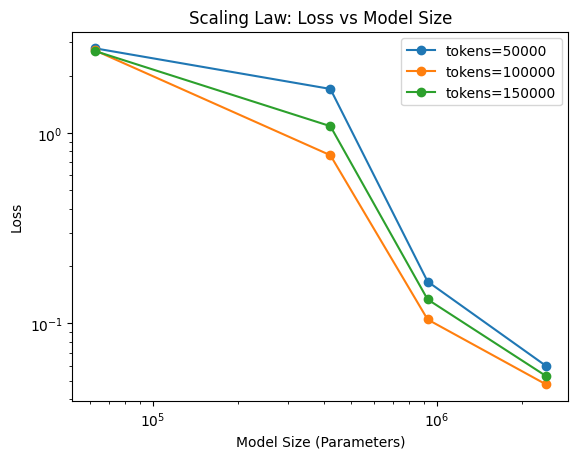

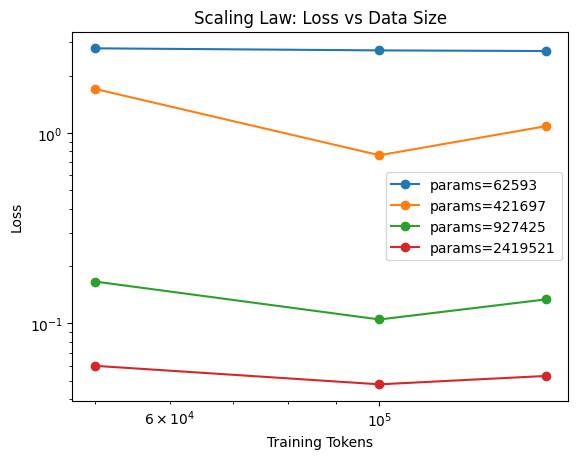

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

results = [
    {'params': 62593, 'tokens': 50000, 'loss': 2.7802},
    {'params': 62593, 'tokens': 100000, 'loss': 2.7115},
    {'params': 62593, 'tokens': 150000, 'loss': 2.6907},

    {'params': 421697, 'tokens': 50000, 'loss': 1.7017},
    {'params': 421697, 'tokens': 100000, 'loss': 0.7636},
    {'params': 421697, 'tokens': 150000, 'loss': 1.0851},

    {'params': 927425, 'tokens': 50000, 'loss': 0.1659},
    {'params': 927425, 'tokens': 100000, 'loss': 0.1049},
    {'params': 927425, 'tokens': 150000, 'loss': 0.1337},

    {'params': 2419521, 'tokens': 50000, 'loss': 0.0599},
    {'params': 2419521, 'tokens': 100000, 'loss': 0.0479},
    {'params': 2419521, 'tokens': 150000, 'loss': 0.0530},
]

# -------------------------
# 1️⃣ 按 token 分组（画 model scaling）
# -------------------------
group_by_tokens = defaultdict(list)
for r in results:
    group_by_tokens[r['tokens']].append(r)

plt.figure()

for tokens, group in group_by_tokens.items():
    group = sorted(group, key=lambda x: x['params'])
    x = [g['params'] for g in group]
    y = [g['loss'] for g in group]

    plt.plot(x, y, marker='o', label=f"tokens={tokens}")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Model Size (Parameters)")
plt.ylabel("Loss")
plt.title("Scaling Law: Loss vs Model Size")
plt.legend()

plt.show()

# -------------------------
# 2️⃣ 按 model 分组（画 data scaling）
# -------------------------
group_by_params = defaultdict(list)
for r in results:
    group_by_params[r['params']].append(r)

plt.figure()

for params, group in group_by_params.items():
    group = sorted(group, key=lambda x: x['tokens'])
    x = [g['tokens'] for g in group]
    y = [g['loss'] for g in group]

    plt.plot(x, y, marker='o', label=f"params={params}")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Training Tokens")
plt.ylabel("Loss")
plt.title("Scaling Law: Loss vs Data Size")
plt.legend()

plt.show()

The log-log plot of loss versus model size shows a clear decreasing trend across all token budgets, indicating that larger models consistently achieve better performance. The relationship appears approximately linear in log-log space, suggesting a power-law scaling behavior. The relationship between loss and training tokens is generally decreasing but exhibits some inconsistencies, particularly for mid-sized models. This is likely due to limited training steps and stochastic optimization effects in the small-scale regime. Diminishing returns begin to appear when the model size exceeds approximately 1M parameters, where further increases in scale lead to smaller improvements in loss. Overall, despite minor noise, the observed trends are consistent with the general intuition of scaling laws.

#Part C

The results are generally consitant with the expected behaviro of scaling laws. There is some noise from the small experimental set up. As model size increases from about 62K parameters to over 2.4M parameters, the loss consistently decreases across all token budgets. This matches the idea that larger models have a higher capacity and can fit the data better. Yet, performance and token budget is less stable. While increasing the number of training tokens often improves performance (for example in the 64 and 192 hidden size models), there are cases where loss increases with more data, such as in the 128 and 256 models at 150K tokens. This likely happens because the models are not fully trained (only 200 steps), so additional data does not always translate into better performance.


A major limitation of the experiment is the small dataset. It's size leads to overfitting and high variance in validaiton loss for larger models. Also, we used the same learning rate and optimizer setting for all model sizes. This maybe be limitiing as different scale often need different hyperparameters. Both of these factors cause noise and make the trends less clear than expected.

Equal-Compute Comparison: Smaller Model + More Data vs. Larger Model + Less Data

To test how to best allocate a fixed compute budget, we compare two configurations with roughly equivalent FLOPs (compute ≈ params × tokens):

| Configuration | Params | Tokens | Approx. FLOPs | Final Loss |
|---|---|---|---|---|
| Smaller model, more data | 421,697 | 150,000 | ~6.3 × 10¹⁰ | 1.0851 |
| Larger model, less data | 927,425 | 50,000 | ~4.6 × 10¹⁰ | 0.1659 |

The larger model trained on fewer tokens achieves a much lower loss (0.17 vs. 1.09), even though both configurations cost roughly the same amount of compute.

This suggests that under a fixed compute budget, scaling up model size is more valuable than training longer on more data, at least in this regime. A larger model has more parameters to capture patterns in the data, and that capacity advantage outweighs the benefit of additional gradient updates on a smaller model.

This finding is consistent with the Chinchilla scaling laws, which showed that most language models are undertrained relative to their size, meaning you get more out of your compute budget by growing the model than by feeding it more tokens.

#Final Results
| Configuration        | Params   | Tokens  | Approx. FLOPs   | Final Loss |
|---------------------|----------|---------|-----------------|------------|
| Small (64,1)        | 62,593   | 50,000  | ~1.88 × 10¹⁰    | 2.7802     |
| Small (64,1)        | 62,593   | 100,000 | ~3.76 × 10¹⁰    | 2.7115     |
| Small (64,1)        | 62,593   | 150,000 | ~5.63 × 10¹⁰    | 2.6907     |
| Medium (128,2)      | 421,697  | 50,000  | ~1.27 × 10¹¹    | 1.7017     |
| Medium (128,2)      | 421,697  | 100,000 | ~2.53 × 10¹¹    | 0.7636     |
| Medium (128,2)      | 421,697  | 150,000 | ~3.80 × 10¹¹    | 1.0851     |
| Large (192,2)       | 927,425  | 50,000  | ~2.78 × 10¹¹    | 0.1659     |
| Large (192,2)       | 927,425  | 100,000 | ~5.56 × 10¹¹    | 0.1049     |
| Large (192,2)       | 927,425  | 150,000 | ~8.35 × 10¹¹    | 0.1337     |
| X-Large (256,3)     | 2,419,521| 50,000  | ~7.26 × 10¹¹    | 0.0599     |
| X-Large (256,3)     | 2,419,521| 100,000 | ~1.45 × 10¹²    | 0.0479     |
| X-Large (256,3)     | 2,419,521| 150,000 | ~2.18 × 10¹²    | 0.0530     |